## 5. Modelado y evaluación

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings

from pathlib import Path
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)

import optuna


# Paths
X_train_in = Path("../data/modeling/supervised/X_train.parquet")
X_test_in = Path("../data/modeling/supervised/X_test.parquet")
y_train_in = Path("../data/modeling/supervised/y_train.parquet")
y_test_in = Path("../data/modeling/supervised/y_test.parquet")

X_train_N_in = Path("../data/modeling/unsupervised/X_train_N.parquet")
X_test_N_in = Path("../data/modeling/unsupervised/X_test_N.parquet")
y_test_N_in = Path("../data/modeling/unsupervised/y_test_N.parquet")

# Add src/ to Python path
sys.path.append(str(Path("../src").resolve()))
from model.evaluation import evaluate_binary, evaluate_multiclass
from model.tunning import tune_xgboost, tune_rf, tune_if, tune_autoencoder

I0000 00:00:1780346239.087291   38352 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


#### 1) Revisión general

Cargo los diferentes conjuntos preparados para usar en los diferentes modelos.

In [2]:
X_train = pd.read_parquet(X_train_in)
X_test = pd.read_parquet(X_test_in)
y_train = pd.read_parquet(y_train_in)
y_test = pd.read_parquet(y_test_in)

X_train_N = pd.read_parquet(X_train_N_in)
X_test_N = pd.read_parquet(X_test_N_in)
y_test_N = pd.read_parquet(y_test_N_in)

Necesito los nombre de las columnas para luego en laimportancia de las variables:

In [3]:
columns = X_train.columns
columns_N = X_train_N.columns

Soluciono un par de errores de tipo pd a np: 

In [4]:
y_train = y_train.squeeze().to_numpy()
y_test = y_test.squeeze().to_numpy()
X_train = X_train.squeeze().to_numpy()
X_test = X_test.squeeze().to_numpy()

In [5]:
X_train_N = X_train_N.squeeze().to_numpy()
X_test_N = X_test_N.squeeze().to_numpy()
y_test_N = y_test_N.squeeze().to_numpy()

#### 2) Modelos Supervisados

Dada la separación hecha en el notebook 4 más la codificación de la variable respuesta en este caso '0' representa Ataque y '1' Benigno.

**XGBoost**

In [4]:
# Weights adjustment
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 0.23960760013846696


In [5]:
warnings.filterwarnings("ignore") # Omit warning in memory usage
best_params = tune_xgboost(X_train, y_train, scale_pos_weight, n_trials=10)
print(best_params)

  0%|          | 0/10 [00:00<?, ?it/s]

/home/adrian/Documentos/TFG/venv/lib/python3.12/site-packages/xgboost/core.py:751: UserWarning: [20:54:05] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


{'learning_rate': 0.06872700594236814, 'max_depth': 5, 'subsample': 0.9463987883622811, 'colsample_bytree': 0.9197316968394074, 'min_child_weight': 1}


In [6]:
#best_params={'learning_rate': 0.09890860585819196, 'max_depth': 6, 'subsample': 0.8670642232678142, 'colsample_bytree': 0.9579982000396621, 'min_child_weight': 2, 'gamma': 0.05722614875920762, 'reg_alpha': 0.17154684495225483, 'reg_lambda': 1.9788954698285044}

base_model = XGBClassifier(
    **best_params,
    tree_method="hist",
    device="cuda",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    early_stopping_rounds=100,  # critical for preventing overfitting with high estimators
    verbosity=0,                # eliminates device mismatch warning logs
    random_state=42,
    n_jobs=-1,
    n_estimators=2000           # important for early stopping stability
)

# I wanna avoid bias (ensure X_train was not exposed to target leakage during tuning)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

# Fitting the model
base_model.fit(
    X_tr,
    y_tr,
    eval_set=[(X_val, y_val)],
    verbose=50
)

[0]	validation_0-logloss:0.64138
[50]	validation_0-logloss:0.14874
[100]	validation_0-logloss:0.12974
[150]	validation_0-logloss:0.12340
[200]	validation_0-logloss:0.12016
[250]	validation_0-logloss:0.11798
[300]	validation_0-logloss:0.11621
[350]	validation_0-logloss:0.11482
[400]	validation_0-logloss:0.11359
[450]	validation_0-logloss:0.11264
[500]	validation_0-logloss:0.11166
[550]	validation_0-logloss:0.11089
[600]	validation_0-logloss:0.11025
[650]	validation_0-logloss:0.10970
[700]	validation_0-logloss:0.10918
[750]	validation_0-logloss:0.10860
[800]	validation_0-logloss:0.10806
[850]	validation_0-logloss:0.10765
[900]	validation_0-logloss:0.10725
[950]	validation_0-logloss:0.10692
[1000]	validation_0-logloss:0.10661
[1050]	validation_0-logloss:0.10626
[1100]	validation_0-logloss:0.10595
[1150]	validation_0-logloss:0.10565
[1200]	validation_0-logloss:0.10541
[1250]	validation_0-logloss:0.10514
[1300]	validation_0-logloss:0.10489
[1350]	validation_0-logloss:0.10469
[1400]	validati

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9197316968394074
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",100
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import


Best threshold: 0.24237992

=== CONFUSION MATRIX ===
[[ 73284   9950]
 [   493 346883]]

=== CONFUSION MATRIX (ROW-NORMALIZED) ===


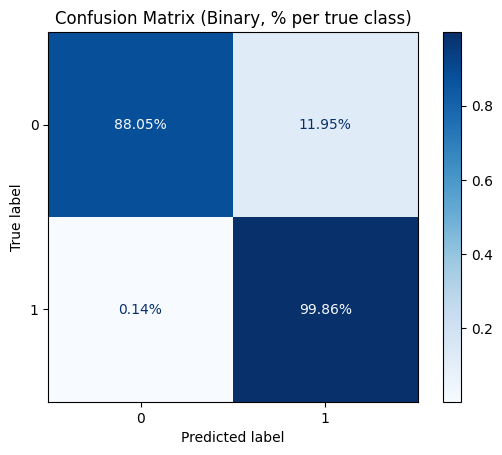


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     83234
           1       0.97      1.00      0.99    347376

    accuracy                           0.98    430610
   macro avg       0.98      0.94      0.96    430610
weighted avg       0.98      0.98      0.98    430610


ROC-AUC: 0.9897866236033799


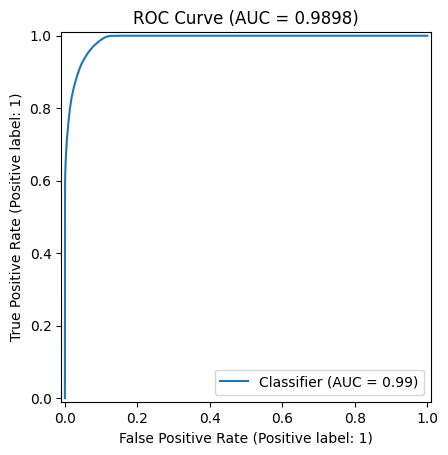

PR-AUC: 0.9973247671784522


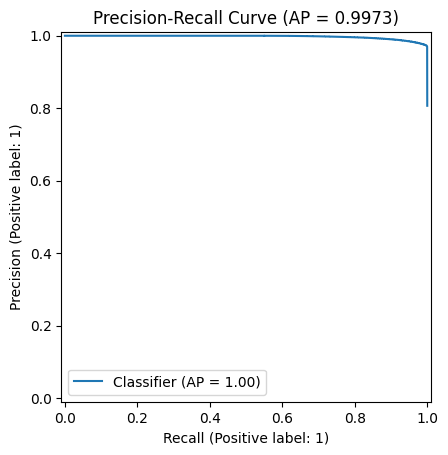

In [7]:
# EVALUATION
X_test_arr = np.asarray(X_test, dtype=np.float32)
y_proba = base_model.get_booster().inplace_predict(X_test_arr, predict_type="probability")
evaluate_binary(y_proba, y_test)

In [12]:
# FEATURE IMPORTANCE 
importance = pd.DataFrame({
    "Feature": columns,
    "Importance": base_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop 20 Features:")
print(importance.head(20))

NameError: name 'base_model' is not defined

**Random Forest**

In [7]:
best_params = tune_rf(X_train, y_train, n_trials=5)
print(best_params)

  0%|          | 0/5 [00:00<?, ?it/s]

{'n_estimators': 69, 'max_depth': 8, 'min_samples_split': 18, 'min_samples_leaf': 11}


In [8]:
rf_model = RandomForestClassifier(
    **best_params,
    max_features="sqrt",      # Safely forces rapid feature split evaluation 
    class_weight="balanced",  # Critical for our dataset with class imbalance
    n_jobs=-1,                # Spreads the final tree building across all CPU cores
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",69
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",18
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",11
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y


Best threshold: 0.36969261848481394

=== CONFUSION MATRIX ===
[[ 71667  11567]
 [   321 347055]]

=== CONFUSION MATRIX (ROW-NORMALIZED) ===


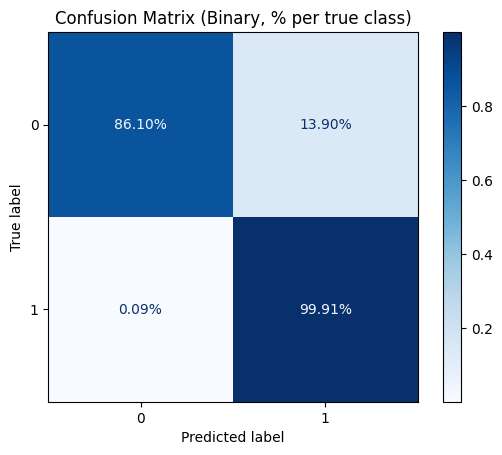


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       1.00      0.86      0.92     83234
           1       0.97      1.00      0.98    347376

    accuracy                           0.97    430610
   macro avg       0.98      0.93      0.95    430610
weighted avg       0.97      0.97      0.97    430610


ROC-AUC: 0.9796355543426943


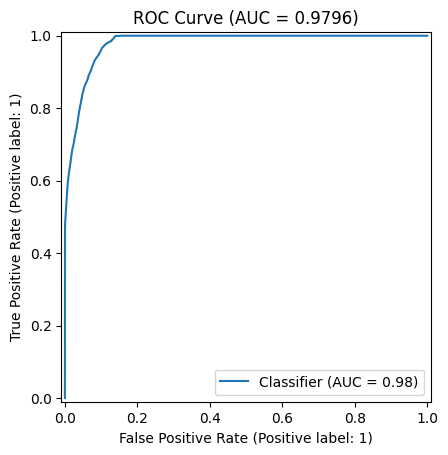

PR-AUC: 0.9943393057893484


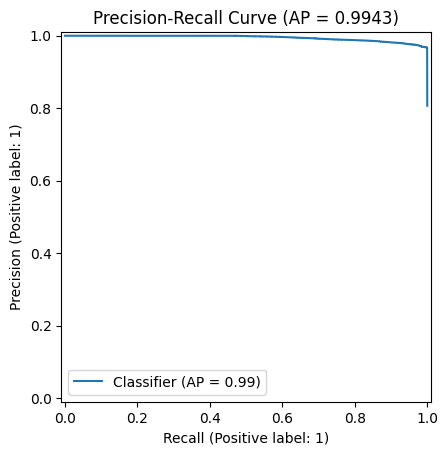

In [9]:
# EVAUATION
y_proba = rf_model.predict_proba(X_test)[:, 1]
evaluate_binary(y_proba, y_test)

In [15]:
# FEATURE IMPORTANCE 
importance = pd.DataFrame({
    "Feature": columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop 20 Features (Random Forest):")
print(importance.head(20))


Top 20 Features (Random Forest):
                   Feature  Importance
47       Init Fwd Win Byts    0.128077
23             Fwd IAT Min    0.079756
9          Bwd Pkt Len Max    0.056808
49        Fwd Seg Size Min    0.053490
34             Pkt Len Max    0.041562
4          TotLen Bwd Pkts    0.040753
7         Fwd Pkt Len Mean    0.040226
48       Init Bwd Win Byts    0.037923
12         Bwd Pkt Len Std    0.027749
11        Bwd Pkt Len Mean    0.027613
5          Fwd Pkt Len Max    0.027176
2             Tot Bwd Pkts    0.027099
19             Fwd IAT Tot    0.026702
67        Dst Port Cat_web    0.022079
26             Bwd IAT Std    0.021461
31              Fwd Pkts/s    0.021402
36             Pkt Len Std    0.019247
18            Flow IAT Min    0.018952
63  Dst Port Cat_ephemeral    0.018240
32              Bwd Pkts/s    0.017780


#### 3) Modelos No Supervisados

**Isolation Forest**

In [57]:
best_params = tune_if(X_train_N, n_trials=5)
print(best_params)

[I 2026-05-30 20:08:33,312] A new study created in memory with name: no-name-74729f66-1ac6-4341-bf97-a49f3e5ca071
[I 2026-05-30 20:15:42,918] Trial 0 finished with value: 0.058672138173431594 and parameters: {'n_estimators': 100, 'max_samples': 'auto', 'max_features': 0.8722652720667692, 'contamination': 0.022521492969389316}. Best is trial 0 with value: 0.058672138173431594.
[I 2026-05-30 20:22:37,159] Trial 1 finished with value: 0.06252486051423795 and parameters: {'n_estimators': 100, 'max_samples': 'auto', 'max_features': 0.8463866008353377, 'contamination': 0.04356600821225217}. Best is trial 0 with value: 0.058672138173431594.
[I 2026-05-30 20:26:57,833] Trial 2 finished with value: 0.06380468443768574 and parameters: {'n_estimators': 62, 'max_samples': 'auto', 'max_features': 0.8493203641274766, 'contamination': 0.07645122593743539}. Best is trial 0 with value: 0.058672138173431594.
[I 2026-05-31 02:49:31,278] Trial 3 finished with value: 0.031098087065650048 and parameters: {'

{'latent_dim': 21, 'lr': 0.00017930199059425827, 'batch_size': 256, 'n1': 56, 'n2': 54, 'dropout': 0.24043288407991234}


In [58]:
if_model = IsolationForest(
    **best_params,

    random_state=42,
    n_jobs=-1
)

# TRAIN (unsupervised: only X_train)
if_model.fit(X_train_N)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",114
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",0.7
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05675425754310635
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",0.8134157289353066
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [59]:
# SCORES
scores = -if_model.decision_function(X_test_N)
# EVALUATION
evaluate_binary(scores, y_test_N)


Best threshold: -0.009562152618812103

=== CONFUSION MATRIX ===
[[321724  25652]
 [ 97314 318855]]

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         0.0       0.77      0.93      0.84    347376
         1.0       0.93      0.77      0.84    416169

    accuracy                           0.84    763545
   macro avg       0.85      0.85      0.84    763545
weighted avg       0.85      0.84      0.84    763545


ROC-AUC: 0.887538921112221
PR-AUC: 0.9034987479331289


**Autoencoder**

In [6]:
best = tune_autoencoder(X_train_N, n_trials=10)
print(best)

  0%|          | 0/10 [00:00<?, ?it/s]

W0000 00:00:1780346288.999553   38352 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


{'latent_dim': 7, 'lr': 0.0012452845659209767, 'batch_size': 256, 'n1': 48, 'n2': 35, 'dropout': 0.0046450412719997725}


In [9]:
inp = layers.Input(shape=(X_train_N.shape[1],))

x = layers.Dense(
    best["n1"], activation="relu",
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
)(inp)

x = layers.Dense(
    best["n2"], activation="relu",
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
)(x)

latent = layers.Dense(best["latent_dim"], activation="relu")(x)

x = layers.Dense(
    best["n2"], activation="relu",
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
)(latent)

x = layers.Dense(
    best["n1"], activation="relu",
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
)(x)

out = layers.Dense(X_train_N.shape[1])(x)

autoencoder = Model(inp, out)

autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best["lr"]),
    loss="mae"
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",          
    patience=5,                  
    restore_best_weights=True    
)

autoencoder.fit(
    X_train_N,
    X_train_N,
    epochs=100,                  
    batch_size=best["batch_size"],
    shuffle=True,
    validation_split=0.15,       
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/100
4614/4614 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 0.4980 - val_loss: 0.1381
Epoch 2/100
4614/4614 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 0.3221 - val_loss: 0.1228
Epoch 3/100
4614/4614 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.3321 - val_loss: 0.1290
Epoch 4/100
4614/4614 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.3020 - val_loss: 0.1232
Epoch 5/100
4614/4614 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 0.3180 - val_loss: 0.2100
Epoch 6/100
4614/4614 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.3384 - val_loss: 0.1097
Epoch 7/100
4614/4614 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.2949 - val_loss: 0.1092
Epoch 8/100
4614/4614 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.2985 - val_loss: 0.0993
Epoch 9/100
4614/4614 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.2609 - val_loss: 0.1307
Epoch 10/100
4614/4614 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 0.2599 - val_loss: 0.0818
Epoch 11/100
4614/4614 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.2419 - val_loss: 0.0881
Epoch 12/

In [10]:
# SCORES (RECONSTRUCTION ERROR)
recon = autoencoder.predict(X_test_N, verbose=0)
scores = np.mean(np.abs(X_test_N - recon), axis=1)
# EVALUATION
evaluate_binary(scores, y_test_N)

ValueError: Invalid dtype: object

In [28]:
# 1. Calculate the Mean Absolute Error (MAE) for each column individually
# (This averages the error across all rows for each feature index)
mae_per_feature = np.mean(np.abs(X_test_N - recon), axis=0)

# 2. Create the feature importance DataFrame using your columns list
ae_importance = pd.DataFrame({
    "Feature": columns_N,
    "Importance_Score": mae_per_feature
}).sort_values(by="Importance_Score", ascending=False)

# 3. Display the top 20 features driving the reconstruction error
print("\nTop 20 Most Important Features (Autoencoder):")
print(ae_importance.head(20))


Top 20 Most Important Features (Autoencoder):
   Feature  Importance_Score
25      25         19.040117
6        6          9.548080
1        1          1.179970
5        5          0.874783
23      23          0.600843
28      28          0.533018
48      48          0.471388
46      46          0.469826
7        7          0.377799
0        0          0.363920
2        2          0.341017
8        8          0.319790
34      34          0.279594
3        3          0.255977
47      47          0.243815
17      17          0.232572
9        9          0.213050
10      10          0.207825
39      39          0.184784
13      13          0.183714
